<a href="https://colab.research.google.com/github/Spatel1309/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is linear when its coefficients are linear (the parameters). The coefficients are multiplied by the inputs and then added together. The inputs can be transformed, but the coefficients can not be for a linear model.

2. Dummy variables are usually categorized as 1 or 0. When the dummy variable equals 0, you get the intercept of the model or the baseline model. When the dummy variable equals 1, the outcome is the baseline plus the coefficient. The dummy variable helps find the difference between with and without the coefficient.

3. A linear regression can be used, but is not suggested as it can produce values that do not make sense for probabilities, such as values less than 0 or greater than 1

4. A big sign for when a model is over-fitting is when it performs well with the training data, but poorly on test data. That means there is a lot of extra noise in the model, and it does not catch the pattern well.

5. Multi-colinearity happens when variables are highly correlated, and it is hard to distinguish the effect they have on the model. With 2SLS, you are trying to find the true effect of a messy variable and multicollinearity makes this harder to do.

6. To incorporate nonlinear relationships, you can transform variables with a square or log, to capture more complex patterns and relationships.

7. Holding all other variables constant, the slope coefficient in a linear regression tells us the change in y for a one-unit increase in x

8. For a train/test split, there is only one split. With k-fold cross validation, the data is split into multiple equal parts and then averages the results are averaged. Train/test split is quicker to implement and use, but k-fold cross-validation is more reliable and accurate.

9. People usually use a k value of 5 or 10. You do not want your k value to be too low because it will be less accurate. You also do not want it to be too high because then you have more variance, and it is slower. 5 to 10 is a good balance between accuracy and variance, but it can depend on the data and model.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


df = pd.read_csv("Q1_clean.csv")

In [13]:
means = df.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean()
print(means)
print("Most expensive on average: ", means["Price"].idxmax())


                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750
Most expensive on average:  Manhattan


Most expenisve on average is Manhattan

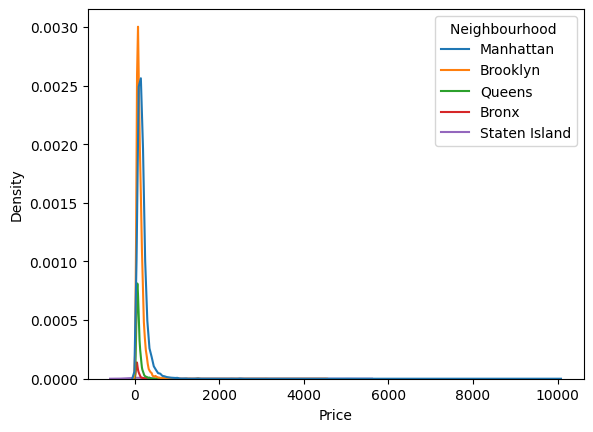

In [14]:
sns.kdeplot(data=df, x="Price", hue="Neighbourhood ")
plt.show()

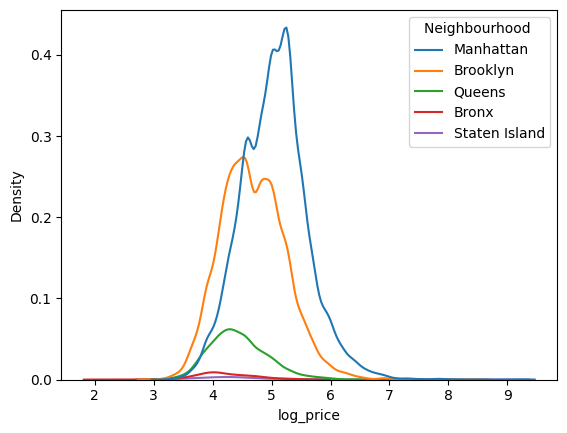

In [15]:
df["log_price"] = np.log(df["Price"])
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood ")
plt.show()

In [21]:
print(df.columns)

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type', 'log_price'],
      dtype='object')


In [23]:
df = df.rename(columns={"Neighbourhood ": "Neighbourhood"})

In [26]:
model = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        20:40:46   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

The intercept is the Bronx (baseline). The regression coefficients equal the difference between the conditional group means (average price) and the baseline (Bronx)

In [27]:
model = smf.ols("Price ~ Q('Review Scores Rating')", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        20:41:03   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

With a intercept (baseline) of 60.88, the slope coefficient indicates that for a one-unit increase in review scores rating, the predicted price increases by about 1.02 units on average, holding other factors constant.

In [28]:
model = smf.ols("Price ~ C(Neighbourhood) + Q('Review Scores Rating')", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        20:41:06   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

The slope slightly increased from 1.02 to 1.08. This means that for a one-unit increase in review scores rating, the predicted price increases by about 1.08 units on average, holding other factors constant. The neighborhood values changed slightly, but nothing significant.

In [29]:
model = smf.ols("Price ~ C(Neighbourhood) * Q('Review Scores Rating')", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:41:09   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

The slopes for Brooklun and Manhattan are similar and small. Queens has a small negative interaction, but Staten Island has a significant negative interaction.  

In [32]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def run_cv(formula, data, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []
    for train, test in kf.split(data):
        train_data = data.iloc[train]
        test_data = data.iloc[test]
        model = smf.ols(formula, data=train_data).fit()
        predictions = model.predict(test_data)
        mse = mean_squared_error(test_data["Price"], predictions)
        errors.append(mse)
    return sum(errors) / len(errors)
q3 = run_cv("Price ~ C(Neighbourhood) + Q('Review Scores Rating')", df)
q4 = run_cv("Price ~ C(Neighbourhood) * Q('Review Scores Rating')", df)

print("Model 3 MSE:", q3)
print("Model 4 MSE:", q4)

Model 3 MSE: 21068.500019790663
Model 4 MSE: 21293.76899859329


Model 3 has a lower MSE than Model 4, so it performs better using cross-validation. Thus, adding interactions doesn't improve the model, but actually makes it slightly worse.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


df = pd.read_csv("cars_hw.csv")

In [34]:
df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


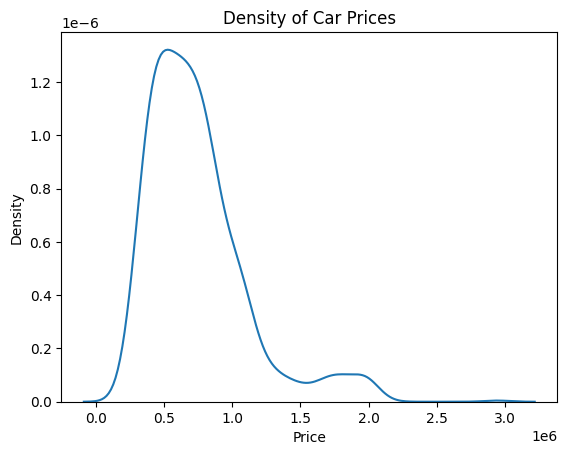

In [35]:
sns.kdeplot(data=df, x="Price")
plt.title("Density of Car Prices")
plt.show()

In [36]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


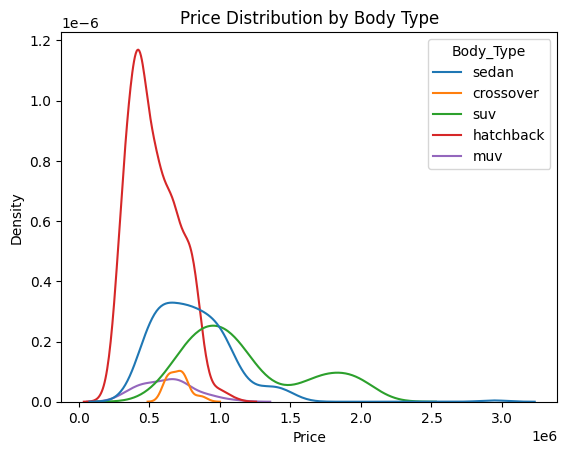

In [38]:
sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.title("Price Distribution by Body Type")
plt.show()

In [40]:
df.groupby("Body_Type")["Price"].mean()

,Price
Body_Type,
crossover,7.050952e+05
hatchback,5.339773e+05
muv,6.264211e+05
sedan,8.097841e+05
suv,1.176495e+06


In [41]:
df.groupby("Body_Type")["Price"].var()

,Price
Body_Type,
crossover,5.307090e+09
hatchback,2.995902e+10
muv,3.389041e+10
sedan,8.221798e+10
suv,1.742887e+11


SUV is the most expensive and has the most variance. On the flipside, hatchback is the cheapest and crossover has the least variance.

In [42]:
model1 = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0245
Time:                        21:09:53   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

The slope coefficient for seating capacity is 59,270. This means for every additional seat, the price increases by 59,270 rupees on average, everything else held constant.

In [45]:
df.groupby("Seating_Capacity")["Price"].mean()

,Price
Seating_Capacity,
4,1.880000e+05
5,7.344839e+05
6,1.644000e+06
7,9.239487e+05
8,4.598000e+05


The difference in prices for the number of seats is not linear. The price difference varies significantly.

In [46]:
df["Age"] = 2026 - df["Make_Year"]

In [47]:
results = {}

for d in range(1, 6):  # try 1 to 5 powers
    formula = "Price ~ " + " + ".join([f"np.power(Age, {i})" for i in range(1, d+1)])
    mse = run_cv(formula, df, k=10)
    results[d] = mse
    print(f"Degree {d}: MSE = {mse}")

Degree 1: MSE = 97745760011.44073
Degree 2: MSE = 97815319552.31638
Degree 3: MSE = 97304076284.38248
Degree 4: MSE = 96785385468.59647
Degree 5: MSE = 95816293469.6781


In [49]:
best_power = min(results, key=results.get)
print("Best power:", best_power)

Best power: 5


The optimal number of powers of Age to include in a regression of Price on Age is 5

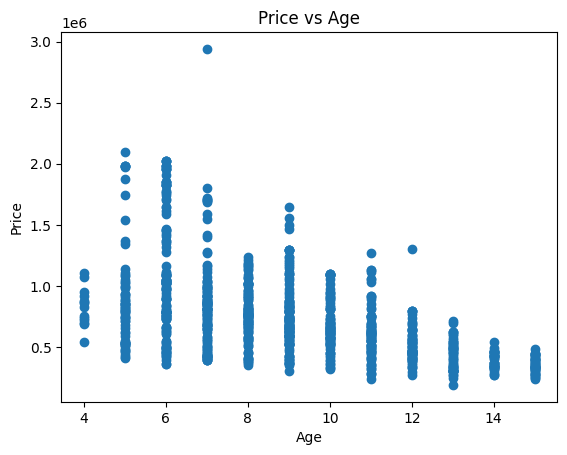

In [51]:
plt.scatter(df["Age"], df["Price"])
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

In [52]:
k = 5

formula = "Price ~ " + " + ".join([f"np.power(Age, {i})" for i in range(1, k+1)])
model = smf.ols(formula, data=df).fit()

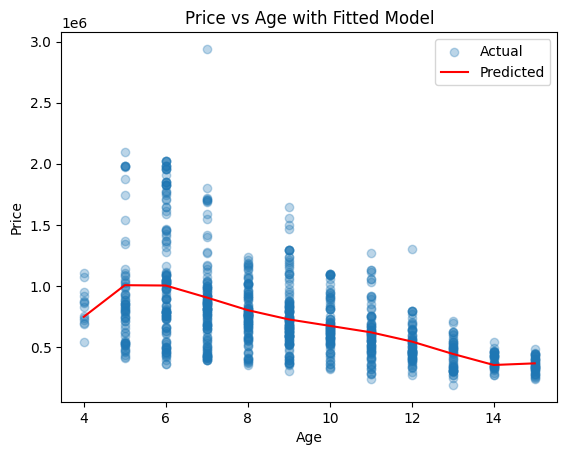

In [53]:
df_sorted = df.sort_values("Age")

preds = model.predict(df_sorted)

plt.scatter(df["Age"], df["Price"], alpha=0.3, label="Actual")
plt.plot(df_sorted["Age"], preds, color="red", label="Predicted")
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Fitted Model")
plt.legend()
plt.show()

The model accurately captures the overall trend in the data, showing that price decreases as age increases. However, it does not capture the variability in prices well.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


df = pd.read_csv("heart_hw.csv")

In [56]:
survival_rates = df.groupby("transplant")["y"].mean()
print(survival_rates)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64


In [57]:
ate = survival_rates["treatment"] - survival_rates["control"]
print("ATE:", ate)

ATE: 0.23017902813299232


The ATE is about 0.2302. Treatment increased probability of survival by 0.2302 or 23 percent

In [58]:
model = smf.ols("y ~ C(transplant)", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0133
Time:                        21:52:58   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The coefficient matches the ATE at around 0.2302

In [59]:
model = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000357
Time:                        21:54:49   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The coefficient on transplant increases after controlling for age from about 23 percent to 26 percent, indicating that age was confounding the relationship between transplant and survival. The intercept represents the predicted survival probability for a control individual at age zero, which is about 70 percent. The predicted treatment effect is constant across ages at approximately 0.265. For every unit increase in age, the probability of survival decreases by about 1 percent.

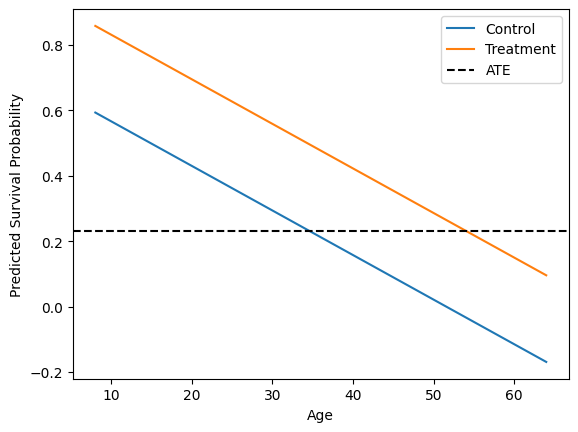

In [60]:
import numpy as np

ages = np.linspace(df["age"].min(), df["age"].max(), 100)

control_pred = model.predict(pd.DataFrame({
    "age": ages,
    "transplant": ["control"]*len(ages)
}))

treat_pred = model.predict(pd.DataFrame({
    "age": ages,
    "transplant": ["treatment"]*len(ages)
}))

plt.plot(ages, control_pred, label="Control")
plt.plot(ages, treat_pred, label="Treatment")

plt.axhline(y=0.23018, linestyle="--", color="black", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

ATE underestimates the effects of transplant at all ages

In [61]:
model2 = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000310
Time:                        22:04:50   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

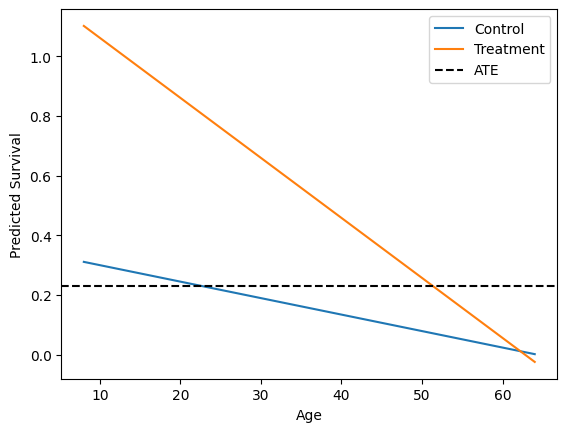

In [62]:
ages = np.linspace(df["age"].min(), df["age"].max(), 100)

control_pred = model2.predict(pd.DataFrame({
    "age": ages,
    "transplant": ["control"]*len(ages)
}))

treat_pred = model2.predict(pd.DataFrame({
    "age": ages,
    "transplant": ["treatment"]*len(ages)
}))

plt.plot(ages, control_pred, label="Control")
plt.plot(ages, treat_pred, label="Treatment")

plt.axhline(y=0.23018, linestyle="--", color="black", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.legend()
plt.show()

The transplant and age interaction changes the model by allowing the treatment effect to vary with age. The predicted survival curves are no longer parallel, and the gap between treatment and control decreases as age increases. This indicates that transplants are more beneficial for younger patients and less effective for older patients. The previous model showed that treatment was constant across all ages

In [64]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def run_cv(formula, data, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []
    for train, test in kf.split(data):
        train_data = data.iloc[train]
        test_data = data.iloc[test]
        model = smf.ols(formula, data=train_data).fit()
        predictions = model.predict(test_data)
        mse = mean_squared_error(test_data["y"], predictions)
        errors.append(mse)
    return sum(errors) / len(errors)


m1 = run_cv("y ~ C(transplant)", df, k=10)
m2 = run_cv("y ~ C(transplant) + age", df, k=10)
m3 = run_cv("y ~ C(transplant) * age", df, k=10)

print("Model 1 MSE:", m1)
print("Model 2 MSE:", m2)
print("Model 3 MSE:", m3)

Model 1 MSE: 0.19497249586192156
Model 2 MSE: 0.17926415954952163
Model 3 MSE: 0.17880206762517423


All 3 models have similar MSE, but model 3 (the one with transplant and age interaction) is best according to MSE

There are several concerns with using this model to prioritize transplant access. The model suggests that younger patients benefit more from transplants, which could lead to prioritizing younger individuals and raising ethical concerns about fairness and equity. Third, the model only includes a few variables (age and transplant status), so it likely omits important factors such as overall health and gender.